# Resources

[1. Problem figuring out the inputs to a fully connected layer from convolutional layer in a CNN](https://stats.stackexchange.com/questions/291935/problem-figuring-out-the-inputs-to-a-fully-connected-layer-from-convolutional-la)

[2. Determining output size for images, giving a pading, stride, input and filter size](https://stats.stackexchange.com/questions/297678/how-to-calculate-optimal-zero-padding-for-convolutional-neural-networks)

In [81]:
from utils.imports import *

### 2.1.c)

This toy experiment yields results that could be easily perceived as hard proof and based upon which one can make the following case: A convolutional neural network is nothing else but a far smarter and well-constrained solution derived from the same basis as the one fully connected layers draw upon. The point of difference between FCN and a 1D-convolutional layer is entirely made from a dimensional mismatch at an output level: the output layer holds 10 neurons and activation maps (2, 5). In spite of this, the content remains exactly the same.

In [237]:
# 1. Declaring the variables (e.g., upper and lower bounds of the random initialization and number of elements equivalent to the number of input neurons);
elements:int = 5
lwb, upb = 0, 10
random_vector= torch.tensor([rdm.randint(lwb,upb) for item in range(elements)], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 2.1 Building the 1DCN and Linearity;
cnv1 = nn.Conv1d(in_channels=1, out_channels=2, padding='same', bias=True, kernel_size=3)
linear1 = nn.Linear(in_features=5, out_features=10, bias=True)

# 2.2 Weight transfer;
# 2.2.1 Zero out all the randomly initialized weights within W matrix of linear1;
linear1.weight.data.zero_()

# 3. Weight transfer loop mechanism
with torch.no_grad():
    linear1.weight.data.zero_()
    linear1.bias.data.zero_()
    all_Kernels = cnv1.weight.data
    pad:int = 1
    # 2. Loop through the 10 output rows
    for record in range(10):
        # 3. Determine which filter to use and calculate the local step 's'
        if record >= 5:
            current_kernel = all_Kernels[1, 0] # Grab filter 1
            s = record - 5                     # s resets to 0-4 for the second half
            linear1.bias.data[record:] = cnv1.bias.data[1]
        else:
            current_kernel = all_Kernels[0, 0] # Grab filter 0
            s = record                         # s is just 0-4 for the first half
            linear1.bias.data[:record] = cnv1.bias.data[0]

        # 4. Loop through the 3 elements of our chosen kernel
        for k in range(len(current_kernel)):
            c = s+k-pad # assigning a particular value of the kernel denoted by `k` at a certain place in weight matrix labelled as `s`
            # 5. Check if the column index is within the matrix bounds (0 to 4)
            if c>=0 and c<5:
                # Place the actual kernel weight into the matrix
                linear1.weight.data[record,c]=current_kernel[k]

print("Final Matrix:")
# print(linear1.weight.data)
# print(linear1.bias.data)

# 5. Feed both the CN and LIN layers with randomly generated tensor vector;
print(cnv1(random_vector))
print(linear1(random_vector))
message_21c = "This toy experiment yields results that could be easily perceived as hard proof and based upon which one can make the following case: A convolutional neural network is nothing else but a far smarter and well-constrained solution derived from the same basis as the one fully connected layers draw upon. The point of difference between FCN and a 1D-convolutional layer is entirely made from a dimensional mismatch at an output level: the output layer holds 10 neurons and activation maps (2, 5). In spite of this, the content remains exactly the same."
write_and_display_Message(message_21c, "2.1.C) Answer")

Final Matrix:
tensor([[[-0.5764,  0.9231,  1.9028,  0.0239,  0.4701],
         [-3.1388, -4.0631, -2.2972, -3.8415, -2.3503]]],
       grad_fn=<ConvolutionBackward0>)
tensor([[[-0.5764,  0.9231,  1.9028,  0.0239,  0.3920, -3.1388, -4.0631,
          -2.2972, -3.8415, -2.3503]]], grad_fn=<ViewBackward0>)


True

### 2.1.d) 
I think I got my answer(s).
Conceptually talking is safe to assume that one feature map is analogue to one neuron, both of which holding different information about the input.
However, seen from a mathematical standpoint the aforementioned statement is not flawless anymore. Mathematically, for a flatten vector holding 1024 neurons one activation map of square size 32*32 will be equivalent.

In order to retain the original shape of the image or preserve its authentic dimension one should adopt zero-padding denoted in programming as padding='same'. The possible values for the padding size, P, depends the input size W (following the notation of the blog), the filter size F and the stride S. We assume width and height are the same. What you need to ensure is that the output size, (W−F+2P)/S+1, is an integer. When S=1 then you get your first equation P=(F−1)/2 as necessary condition. But, in general, you need to consider the three parameters, namely W , F and S in order to determine valid values of P.

At this level, drawing a qualitative comparison between outputs produced by two totally untrained and different in nature networks feels more like deciphering a hardly interpretable code. However, based on the first glance one would see more noisy islands appearing in the output as produced by FCN. This is however not as prevalent in the output produced by CNN wherein less such islands were found.

This induces the following meaning, that the weight sharing mechanism built-in CNN truly helps the network to retain both, spatial (e.g., edges and curves) and contextual information whereas the neurons must learn the association or correlation with their neighbors pretty much by "raw guess" or systematic trial and error.    

#### Toy CNN-Model

In [ ]:
class DefaultCNN(nn.Module):
    def __init__(self, depth_no_cn_lay:int, width_no_kern:list, kernel_size:int|tuple=3,sum:bool = False):
        super().__init__()
        self.depth = depth_no_cn_lay
        self.width = width_no_kern
        self.sum = sum
    
        # 0. Init super module that will later store all the sub-modules:|
        self.n = nn.Sequential()#______________________________________________________________
        # 1. Loop through the list holding the number of x-D convolutional layers to be created|
        for layer in range(self.depth):#________________________________________________
            # 2. Do explicit assignment of `ch_in, ch_out and pool type` for each layers|_____________________________________________
            self.n.append((nn.Conv2d(in_channels=width_no_kern[layer], out_channels=width_no_kern[layer+1],padding='same',kernel_size=kernel_size)))#|
            self.n.append(nn.ReLU())

    def forward(self, x):
        
        x = self.n(x)
        
        if self.sum:      
            print("Printing summary... ",summary(self.n), self.width)
        return x

#### Toy FCN-Model

In [89]:
class DefaultFCN(nn.Module):
    def __init__(self, width:list, depth:int, sum:bool=False):
        super().__init__()
        self.width = width
        self.depth = depth
        self.sum = sum


        # 0. Init super module that will later store all the sub-modules:|
        self.n = nn.Sequential()
        # 1. Loop through the list holding the number of x-D convolutional layers to be created|
        for layer in range(self.depth):
            # 2. Do explicit assignment of `in_fet, out_fet and bias ON/OFF` for each layers
            self.n.append(nn.Linear(in_features=width[layer],out_features=width[layer+1],bias=True))
            self.n.append(nn.ReLU())

    def forward(self,x):
        x = self.n(x)

        if self.sum:      
            print("Printing summary... ",summary(self.n), self.width)
        return x

#### Training 

In [ ]:
# 1. Declaration of utilities (e.g., loader) and model components initialization (such as optimizer and loss criteiron)
train_loader, val_loader, test_loader = create_dataloaders(args.data_dir, args.batch_size)
model = DefaultCNN(depth_no_cn_lay=3, width_no_kern=[32**2, 24**2, 16**2, 32**2], sum=True)
optim = SGD(model.parameters, lr=0.01)
loss = BCELoss()



# Utils (helpers or static methods)

In [13]:
@staticmethod
def write_and_display_Message(message:str, title:str)-> None:
    ct.windll.user32.MessageBoxW(0, message, title, 1)

    return True

In [14]:
@staticmethod
def get_parser_Arguments():
    parser = argparse.ArgumentParser(description="Experiment controller")
    parser.add_argument("--data_dir", type=str, default=r"/DataSets", help="Path where data should be store")
    parser.add_argument("--batch_size", type=int, default=64, help="Mini-batch size controller")

    return parser.parse_known_args()[0]

args = get_parser_Arguments()
print(args.batch_size)

64


# Tests

Loaders of size train 782, val 157 and test 157 were sucessfully initialized
Printing summary...  =================================================================
Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            5,308,992
├─ReLU: 1-2                              --
├─Conv2d: 1-3                            1,327,360
├─ReLU: 1-4                              --
├─Conv2d: 1-5                            2,360,320
├─ReLU: 1-6                              --
Total params: 8,996,672
Trainable params: 8,996,672
Non-trainable params: 0
================================================================= [1024, 576, 256, 1024]
Printing summary...  =================================================================
Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            590,400
├─ReLU: 1-2                              --
├─Linear: 1-3       

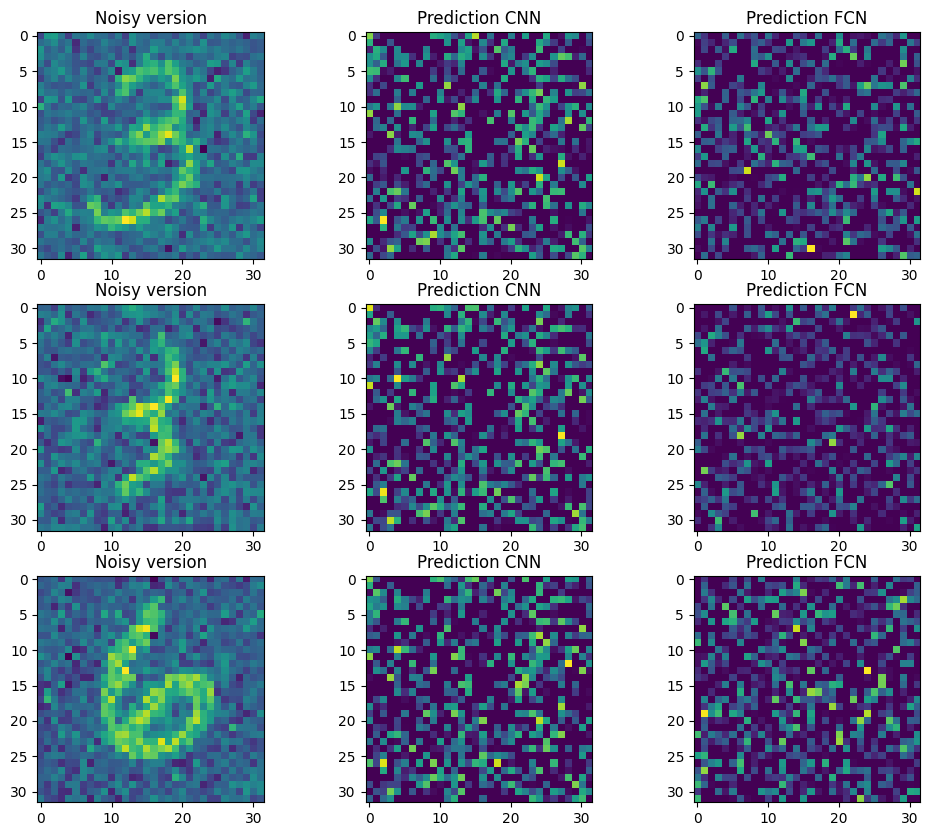

In [97]:
# Sanity Check
args = get_parser_Arguments()
train_loader, val_loader, test_loader = create_dataloaders(args.data_dir, args.batch_size)
print("Loaders of size train {}, val {} and test {} were sucessfully initialized".format(train_loader.__len__(), val_loader.__len__(), test_loader.__len__()))


fig, axis = PLT.subplots(3,3, figsize=(12,10))
for predictions in range(3):
    sample = next(enumerate(test_loader))
    _, (cl, noisy, label) = sample

    model_CNN = DefaultCNN(depth_no_cn_lay=3, width_no_kern=[32**2, 24**2, 16**2, 32**2], sum=True)
    with torch.no_grad():
        model.eval()
        output_CNN = model.forward(noisy[0].reshape(-1,1,32**2).permute(2,0,1))

    model_FCN = DefaultFCN(depth=3, width=[32**2, 24**2, 16**2, 32**2], sum=True)
    with torch.no_grad():
        model.eval()
        output_FCN = model_FCN.forward(noisy[0].reshape(-1,32**2))

    axis[predictions,0].imshow(noisy[0].reshape(32,32))
    axis[predictions,1].imshow(output_CNN.squeeze().reshape(32,32))
    axis[predictions,2].imshow(output_FCN.reshape(32,32))
    axis[predictions,0].set_title(f"Noisy version")
    axis[predictions,1].set_title(f"Prediction CNN")
    axis[predictions,2].set_title(f"Prediction FCN")

print(f"Reshaping...{noisy[0].reshape(-1,1,32**2).permute(2,0,1).shape}")